# Bandt & Pompe (2002): Permutation Entropy of the Logistic Map

This notebook reproduces the experiment architecture in `experiment_design/permutation_entropy.md` using the core implementation in `core_ntsa/pe.py`.

The main objective is to compare the logistic-map Lyapunov exponent with permutation entropy per symbol, $h_6$ and $h_{12}$, and then inspect finite-sample and noise effects.

## 1. Environment and imports

In [1]:
from math import factorial
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "core_ntsa").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core_ntsa.pe import permutation_entropy

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 4.5), "figure.dpi": 120})

## 2. Reproduction configuration

The paper does not report the initial condition or transient length. This notebook uses $x_0=0.123456789$ and discards 1,000 samples as explicit reproduction choices.

`PAPER_SCALE=False` selects a reduced configuration for development. Set it to `True` for the paper-scale deterministic and finite-sample settings. Paper-scale execution is computationally expensive.

In [2]:
PAPER_SCALE = False
RUN_OPTIONAL_NOISE = False
SAVE_RESULTS = False

R_MIN = 3.5
R_MAX = 4.0
X0 = 0.123456789
TRANSIENT = 1_000
RANDOM_SEED = 2026

if PAPER_SCALE:
    N_R = 5_001
    SWEEP_LENGTH = 1_000_000
    FINITE_LENGTHS = (100, 1_000, 10_000, 100_000, 1_000_000)
    FINITE_REPETITIONS = 1_000
    FINITE_ORDERS = tuple(range(3, 16))
else:
    N_R = 81
    SWEEP_LENGTH = 1_500
    FINITE_LENGTHS = (100, 300, 1_000, 3_000)
    FINITE_REPETITIONS = 12
    FINITE_ORDERS = tuple(range(3, 11))

R_VALUES = np.linspace(R_MIN, R_MAX, N_R)

pd.Series({
    "paper_scale": PAPER_SCALE,
    "number_of_r_values": N_R,
    "sweep_length": SWEEP_LENGTH,
    "transient": TRANSIENT,
    "finite_repetitions": FINITE_REPETITIONS,
    "optional_noise": RUN_OPTIONAL_NOISE,
}, name="value")

paper_scale           False
number_of_r_values       81
sweep_length           1500
transient              1000
finite_repetitions       12
optional_noise        False
Name: value, dtype: object

## 3. Logistic-map generator and transient removal

The deterministic map is $x_{t+1}=r x_t(1-x_t)$. Dynamical noise is optional. Noisy states are clipped to $[0,1]$ to keep the stochastic orbit bounded; this is an explicit numerical reproduction choice.

In [3]:
def generate_logistic_map(
    r,
    n_samples,
    x0=X0,
    dynamical_noise=0.0,
    rng=None,
):
    """Generate a deterministic or noisy logistic-map orbit."""
    if not 0.0 < x0 < 1.0:
        raise ValueError("x0 must lie strictly between 0 and 1.")
    if n_samples < 1:
        raise ValueError("n_samples must be positive.")
    if dynamical_noise < 0.0:
        raise ValueError("dynamical_noise must be non-negative.")

    generator = np.random.default_rng(rng)
    orbit = np.empty(n_samples, dtype=np.float64)
    orbit[0] = x0

    for index in range(1, n_samples):
        next_state = r * orbit[index - 1] * (1.0 - orbit[index - 1])
        if dynamical_noise > 0.0:
            next_state += generator.normal(0.0, dynamical_noise)
            next_state = np.clip(next_state, 0.0, 1.0)
        orbit[index] = next_state

    return orbit


def discard_transient(orbit, transient):
    """Remove the initial transient from an orbit."""
    values = np.asarray(orbit, dtype=np.float64)
    if transient < 0 or transient >= values.size:
        raise ValueError("transient must leave at least one sample.")
    return values[transient:].copy()


def generate_post_transient(
    r,
    length,
    transient=TRANSIENT,
    x0=X0,
    dynamical_noise=0.0,
    rng=None,
):
    """Generate and retain a post-transient trajectory."""
    orbit = generate_logistic_map(
        r=r,
        n_samples=transient + length,
        x0=x0,
        dynamical_noise=dynamical_noise,
        rng=rng,
    )
    return discard_transient(orbit, transient)

## 4. Logistic-map Lyapunov exponent

The estimate uses the same post-transient trajectory as PE:

$$λ(r)=(1/T) sum_t log_2|r(1-2x_t)|.$$

In [4]:
def compute_logistic_lyapunov(series, r):
    """Estimate the logistic-map Lyapunov exponent in bits."""
    values = np.asarray(series, dtype=np.float64)
    derivatives = np.abs(r * (1.0 - 2.0 * values))
    with np.errstate(divide="ignore"):
        return float(np.mean(np.log2(derivatives)))

## 5. Stage 1: deterministic sanity check

Representative parameters cover a low-period regime, a chaotic regime, the period-3 window, and fully developed chaos at $r=4$. Exact ties are resolved with the core `jitter` policy and a fixed seed. In float64 arithmetic, an attracting cycle can collapse to exactly repeated values; random tie resolution can therefore raise high-order PE inside a periodic window, so the observed-pattern counts must be inspected with the entropy values.

In [5]:
representative_r = {
    "periodic": 3.55,
    "chaotic": 3.70,
    "period_3_window": 3.83,
    "fully_chaotic": 4.00,
}

sanity_records = []
for label, r_value in representative_r.items():
    signal = generate_post_transient(r_value, 5_000)
    result_6 = permutation_entropy(
        signal, order=6, tie_method="jitter", random_state=RANDOM_SEED
    )
    result_12 = permutation_entropy(
        signal, order=12, tie_method="jitter", random_state=RANDOM_SEED
    )
    sanity_records.append({
        "regime": label,
        "r": r_value,
        "lyapunov": compute_logistic_lyapunov(signal, r_value),
        "h6": result_6.entropy_per_symbol,
        "h12": result_12.entropy_per_symbol,
        "observed_patterns_h6": result_6.number_of_observed_patterns,
        "observed_patterns_h12": result_12.number_of_observed_patterns,
    })

sanity_df = pd.DataFrame(sanity_records)
sanity_df

,regime,r,lyapunov,h6,h12,observed_patterns_h6,observed_patterns_h12
0,periodic,3.55,-0.144114,0.600000,0.635003,8,128
1,chaotic,3.70,0.496703,0.790951,0.711511,18,327
2,period_3_window,3.83,-0.533795,0.916373,1.106776,24,4718
3,fully_chaotic,4.00,1.000610,1.193724,1.059767,75,3597


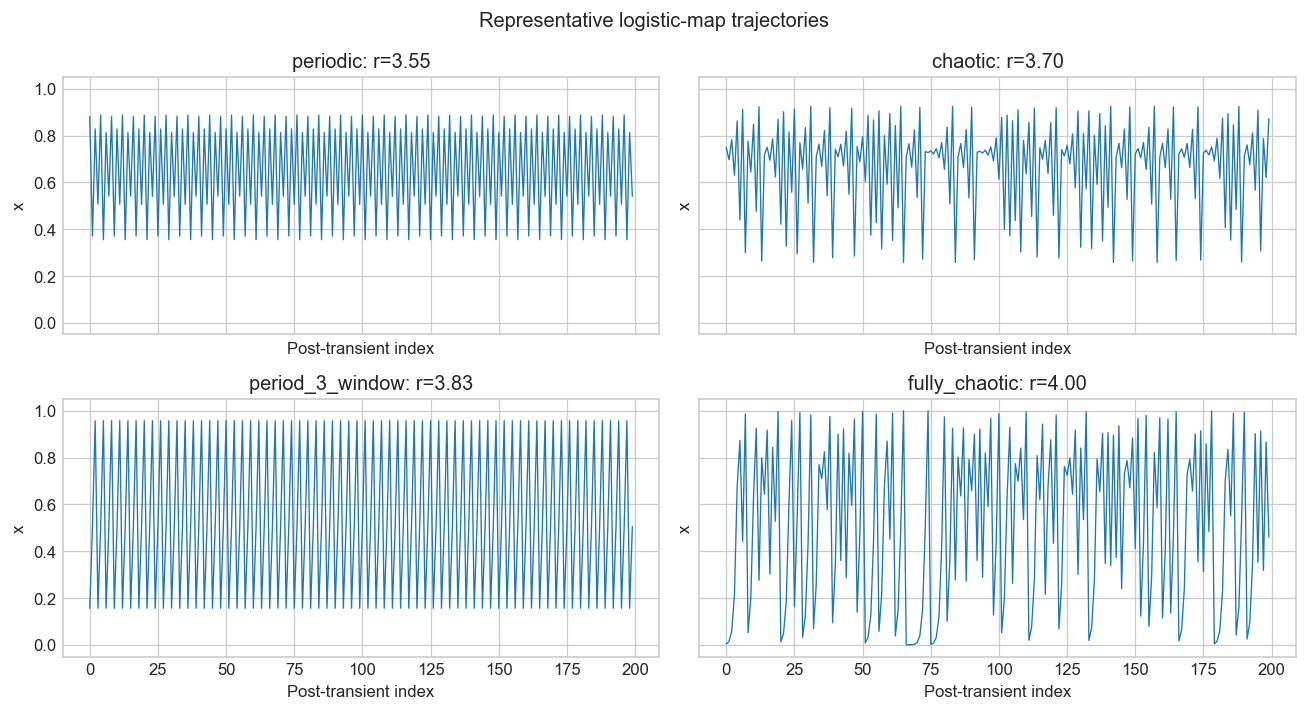

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)
for axis, (label, r_value) in zip(axes.flat, representative_r.items()):
    signal = generate_post_transient(r_value, 200)
    axis.plot(signal, linewidth=0.8)
    axis.set_title(f"{label}: r={r_value:.2f}")
    axis.set_xlabel("Post-transient index")
    axis.set_ylabel("x")
fig.suptitle("Representative logistic-map trajectories")
fig.tight_layout()
plt.show()

## 6. Stage 2 and 3: PE parameter sweep

For each $r$, one post-transient trajectory is shared by the Lyapunov, $h_6$, and $h_{12}$ calculations. The returned table has the paper-compatible columns `r`, `lyapunov`, `h6`, and `h12`.

In [7]:
def compute_pe_parameter_sweep(
    r_values,
    length,
    orders=(6, 12),
    transient=TRANSIENT,
    x0=X0,
    random_state=RANDOM_SEED,
):
    """Compute Lyapunov and PE profiles across logistic parameters."""
    records = []

    for r_index, r_value in enumerate(r_values):
        signal = generate_post_transient(
            r=r_value,
            length=length,
            transient=transient,
            x0=x0,
        )
        record = {
            "r": float(r_value),
            "lyapunov": compute_logistic_lyapunov(signal, r_value),
        }

        for order in orders:
            result = permutation_entropy(
                signal,
                order=order,
                tie_method="jitter",
                random_state=random_state + r_index + order,
            )
            record[f"h{order}"] = result.entropy_per_symbol
            record[f"observed_h{order}"] = (
                result.number_of_observed_patterns
            )
        records.append(record)

    return pd.DataFrame.from_records(records)

In [8]:
sweep_df = compute_pe_parameter_sweep(
    r_values=R_VALUES,
    length=SWEEP_LENGTH,
)
sweep_df.head()

,r,lyapunov,h6,observed_h6,h12,observed_h12
0,3.50000,-1.258762,0.798932,16,0.935371,1308
1,3.50625,-0.652398,0.600000,8,0.631162,128
2,3.51250,-0.436026,0.600000,8,0.631428,128
3,3.51875,-0.300616,0.798759,16,0.935127,1306
4,3.52500,-0.201541,0.798676,16,0.935203,1306


### 6.1 Output A1: bifurcation diagram

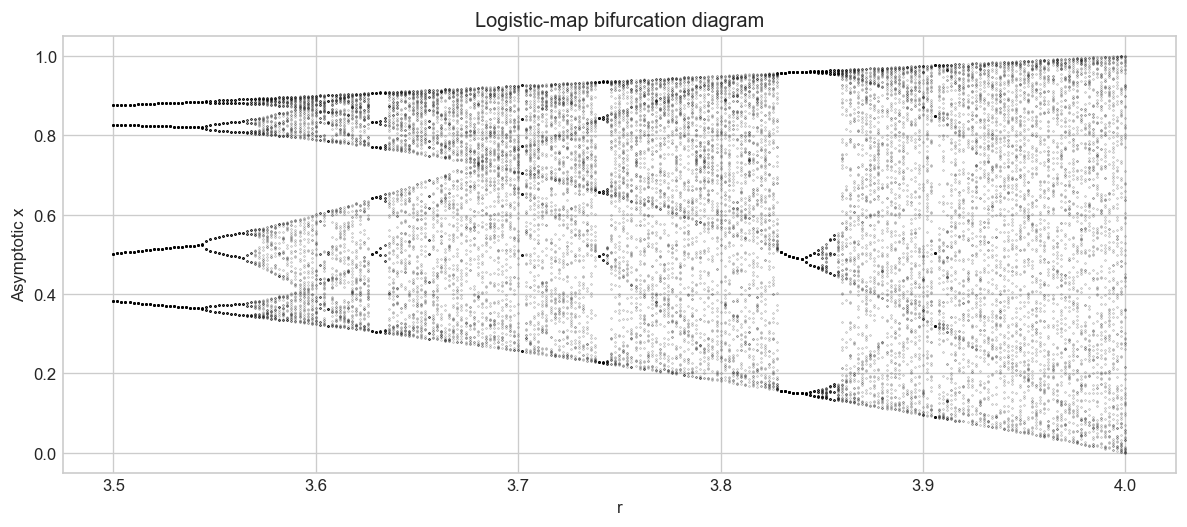

In [9]:
def compute_bifurcation_data(
    r_values,
    retained_samples=100,
    transient=TRANSIENT,
    x0=X0,
):
    """Create long-form asymptotic data for a bifurcation plot."""
    r_columns = []
    x_columns = []

    for r_value in r_values:
        signal = generate_post_transient(
            r_value, retained_samples, transient=transient, x0=x0
        )
        r_columns.append(np.full(retained_samples, r_value))
        x_columns.append(signal)

    return pd.DataFrame({
        "r": np.concatenate(r_columns),
        "asymptotic_x": np.concatenate(x_columns),
    })


bifurcation_r = np.linspace(R_MIN, R_MAX, 501 if PAPER_SCALE else 251)
bifurcation_df = compute_bifurcation_data(bifurcation_r)

fig, ax = plt.subplots()
ax.scatter(
    bifurcation_df["r"],
    bifurcation_df["asymptotic_x"],
    s=0.08,
    color="black",
    alpha=0.4,
)
ax.set(xlabel="r", ylabel="Asymptotic x", title="Logistic-map bifurcation diagram")
fig.tight_layout()
plt.show()

### 6.2 Output A2: Lyapunov exponent

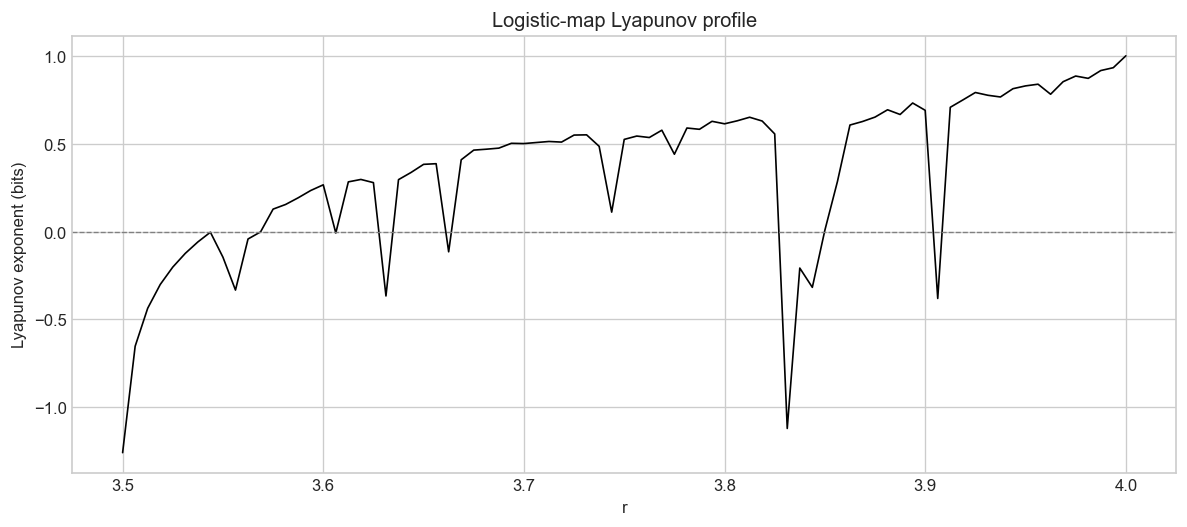

In [10]:
fig, ax = plt.subplots()
ax.plot(sweep_df["r"], sweep_df["lyapunov"], color="black", linewidth=1.0)
ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax.set(
    xlabel="r",
    ylabel="Lyapunov exponent (bits)",
    title="Logistic-map Lyapunov profile",
)
fig.tight_layout()
plt.show()

### 6.3 Output A3: permutation entropy $h_6(r)$

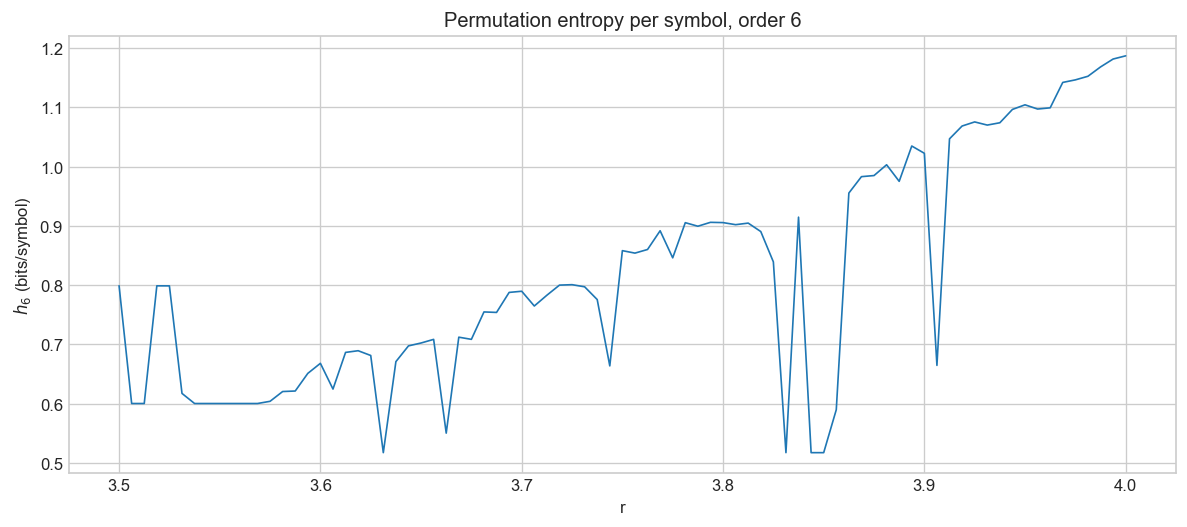

In [11]:
fig, ax = plt.subplots()
ax.plot(sweep_df["r"], sweep_df["h6"], color="tab:blue", linewidth=1.0)
ax.set(
    xlabel="r",
    ylabel="$h_6$ (bits/symbol)",
    title="Permutation entropy per symbol, order 6",
)
fig.tight_layout()
plt.show()

### 6.4 Output A4: permutation entropy $h_{12}(r)$

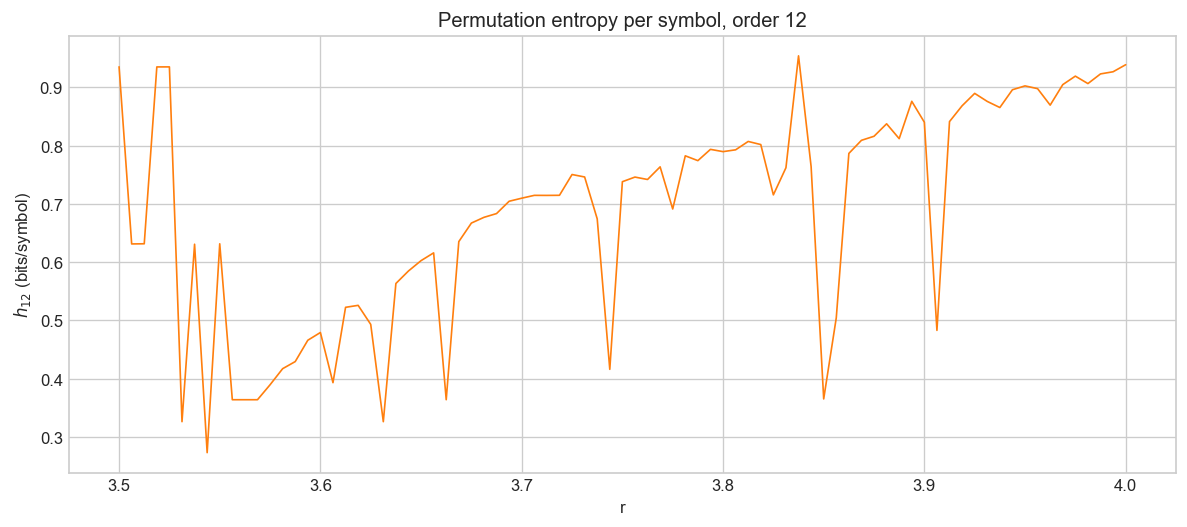

In [12]:
fig, ax = plt.subplots()
ax.plot(sweep_df["r"], sweep_df["h12"], color="tab:orange", linewidth=1.0)
ax.set(
    xlabel="r",
    ylabel="$h_{12}$ (bits/symbol)",
    title="Permutation entropy per symbol, order 12",
)
fig.tight_layout()
plt.show()

### 6.5 Main reproduction criterion

The target is qualitative structural agreement, not pointwise equality. Spearman correlation is reported only over finite, chaotic points with $λ>0$.

In [13]:
finite_mask = np.isfinite(sweep_df[["lyapunov", "h6", "h12"]]).all(axis=1)
chaotic_mask = finite_mask & (sweep_df["lyapunov"] > 0.0)

correlation_df = pd.DataFrame({
    "comparison": ["lyapunov_vs_h6", "lyapunov_vs_h12", "h6_vs_h12"],
    "spearman_rho": [
        spearmanr(
            sweep_df.loc[chaotic_mask, "lyapunov"],
            sweep_df.loc[chaotic_mask, "h6"],
        ).statistic,
        spearmanr(
            sweep_df.loc[chaotic_mask, "lyapunov"],
            sweep_df.loc[chaotic_mask, "h12"],
        ).statistic,
        spearmanr(
            sweep_df.loc[chaotic_mask, "h6"],
            sweep_df.loc[chaotic_mask, "h12"],
        ).statistic,
    ],
})
correlation_df

,comparison,spearman_rho
0,lyapunov_vs_h6,0.985394
1,lyapunov_vs_h12,0.996777
2,h6_vs_h12,0.988668


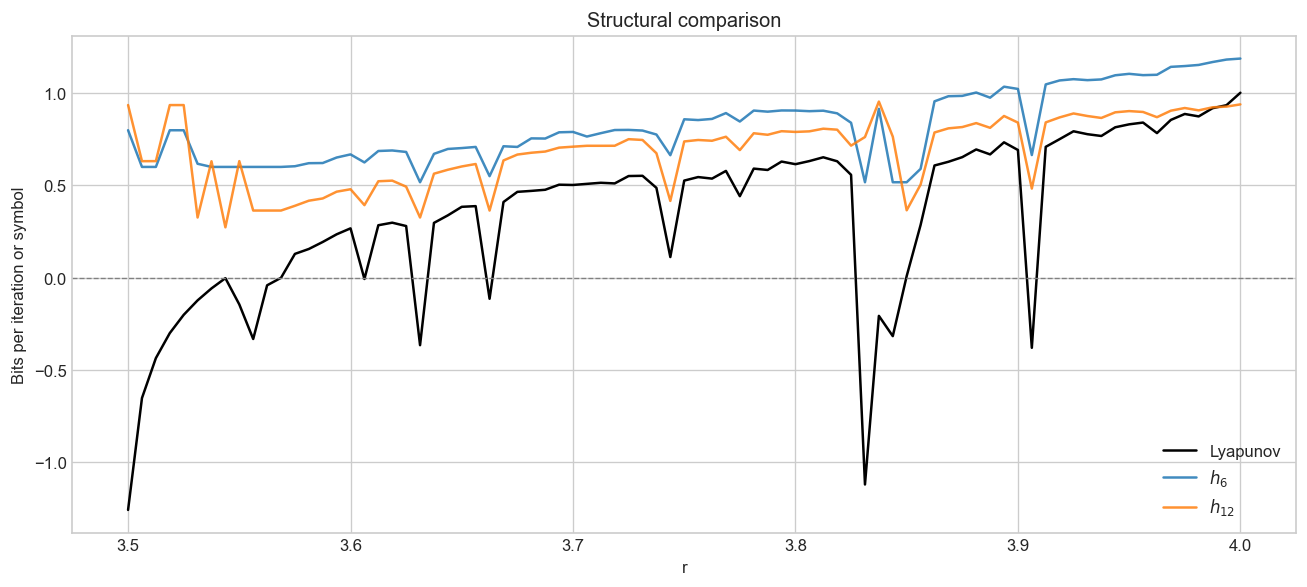

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sweep_df["r"], sweep_df["lyapunov"], label="Lyapunov", color="black")
ax.plot(sweep_df["r"], sweep_df["h6"], label="$h_6$", alpha=0.85)
ax.plot(sweep_df["r"], sweep_df["h12"], label="$h_{12}$", alpha=0.85)
ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax.set(xlabel="r", ylabel="Bits per iteration or symbol", title="Structural comparison")
ax.legend()
fig.tight_layout()
plt.show()

## 7. Experiment B: order comparison

This section compares $h_6$ and $h_{12}$ directly and stores their signed difference.

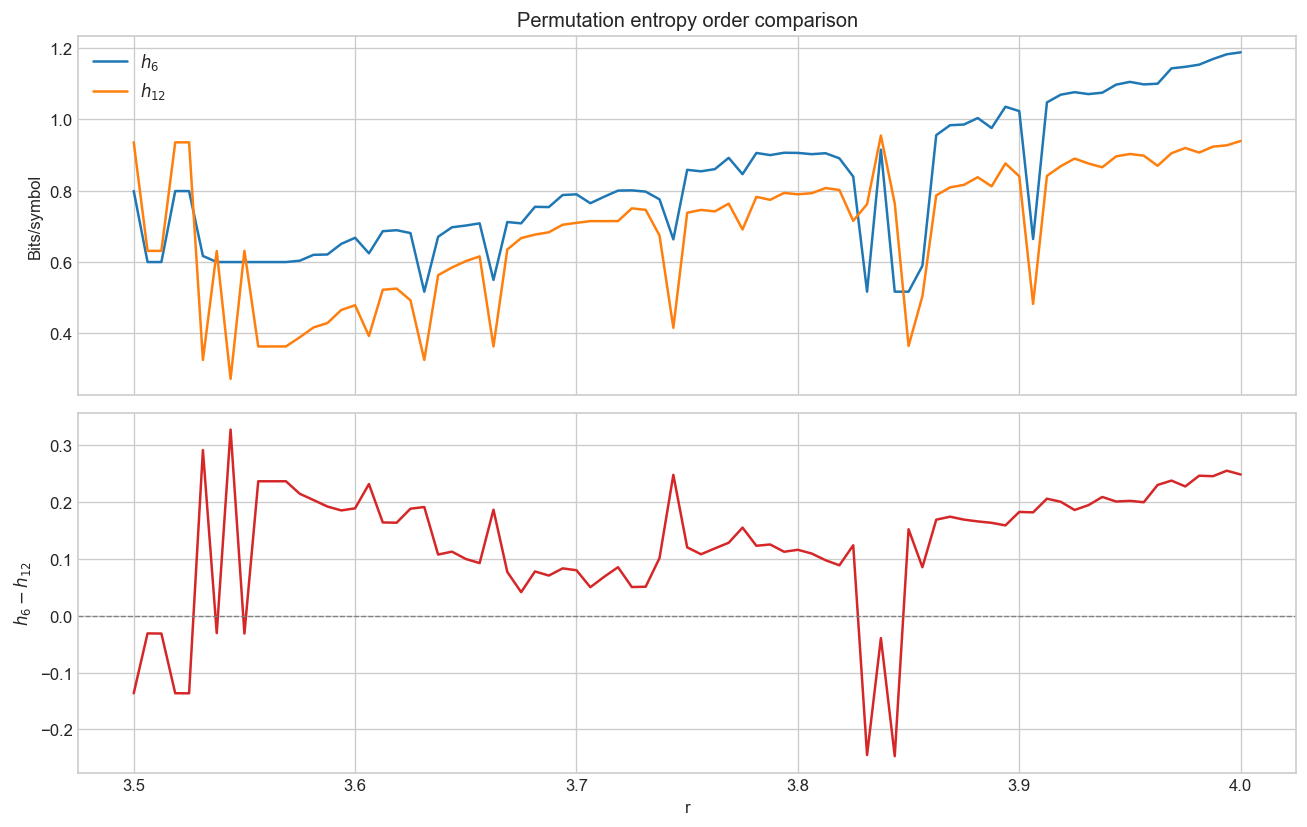

,r,h6,h12,difference
0,3.50000,0.798932,0.935371,-0.136439
1,3.50625,0.600000,0.631162,-0.031162
2,3.51250,0.600000,0.631428,-0.031428
3,3.51875,0.798759,0.935127,-0.136367
4,3.52500,0.798676,0.935203,-0.136526


In [15]:
order_comparison_df = sweep_df[["r", "h6", "h12"]].copy()
order_comparison_df["difference"] = (
    order_comparison_df["h6"] - order_comparison_df["h12"]
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(order_comparison_df["r"], order_comparison_df["h6"], label="$h_6$")
axes[0].plot(order_comparison_df["r"], order_comparison_df["h12"], label="$h_{12}$")
axes[0].set_ylabel("Bits/symbol")
axes[0].set_title("Permutation entropy order comparison")
axes[0].legend()
axes[1].plot(
    order_comparison_df["r"],
    order_comparison_df["difference"],
    color="tab:red",
)
axes[1].axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set(xlabel="r", ylabel="$h_6-h_{12}$")
fig.tight_layout()
plt.show()

order_comparison_df.head()

## 8. Experiment C: finite-sample behavior at $r=4$

Each realization uses an independent initial condition. For every $(T,n)$ pair, the experiment records $h_n$, the number of observed patterns, and the fraction of the $n!$ pattern space observed.

In [16]:
def run_finite_sample_experiment(
    lengths,
    orders,
    repetitions,
    r=4.0,
    transient=TRANSIENT,
    random_state=RANDOM_SEED,
):
    """Estimate finite-sample mean, spread, and pattern coverage."""
    rng = np.random.default_rng(random_state)
    records = []

    for length in lengths:
        for repetition in range(repetitions):
            x0 = rng.uniform(0.05, 0.95)
            signal = generate_post_transient(
                r=r, length=length, transient=transient, x0=x0
            )

            for order in orders:
                if order > length:
                    continue
                result = permutation_entropy(
                    signal,
                    order=order,
                    tie_method="jitter",
                    random_state=random_state + repetition + order,
                )
                records.append({
                    "T": length,
                    "n": order,
                    "repetition": repetition,
                    "h_n": result.entropy_per_symbol,
                    "observed_patterns": result.number_of_observed_patterns,
                    "possible_patterns": factorial(order),
                    "observed_fraction": (
                        result.number_of_observed_patterns / factorial(order)
                    ),
                })

    raw = pd.DataFrame.from_records(records)
    summary = (
        raw.groupby(["T", "n"], as_index=False)
        .agg(
            mean_h=("h_n", "mean"),
            std_h=("h_n", "std"),
            mean_observed_patterns=("observed_patterns", "mean"),
            mean_observed_fraction=("observed_fraction", "mean"),
        )
    )
    summary["possible_patterns"] = summary["n"].map(factorial)
    return raw, summary

In [17]:
finite_raw_df, finite_summary_df = run_finite_sample_experiment(
    lengths=FINITE_LENGTHS,
    orders=FINITE_ORDERS,
    repetitions=FINITE_REPETITIONS,
)
finite_summary_df.head()

,T,n,mean_h,std_h,mean_observed_patterns,mean_observed_fraction,possible_patterns
0,100,3,1.058511,0.057431,5.000000,0.833333,6
1,100,4,1.097716,0.025513,11.750000,0.489583,24
2,100,5,1.111300,0.028868,27.000000,0.225000,120
3,100,6,1.069565,0.023097,48.916667,0.067940,720
4,100,7,0.989471,0.017757,68.333333,0.013558,5040


### 8.1 Figure 3A style: mean $h_n$

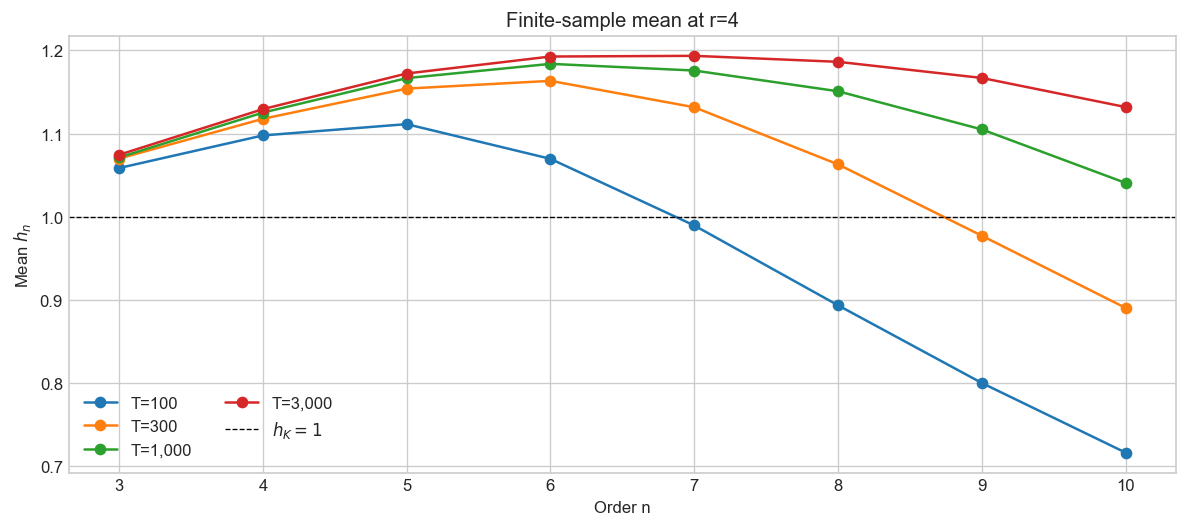

In [18]:
fig, ax = plt.subplots()
for length, group in finite_summary_df.groupby("T"):
    ax.plot(group["n"], group["mean_h"], marker="o", label=f"T={length:,}")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="$h_K=1$")
ax.set(xlabel="Order n", ylabel="Mean $h_n$", title="Finite-sample mean at r=4")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

### 8.2 Figure 3B style: standard deviation of $h_n$

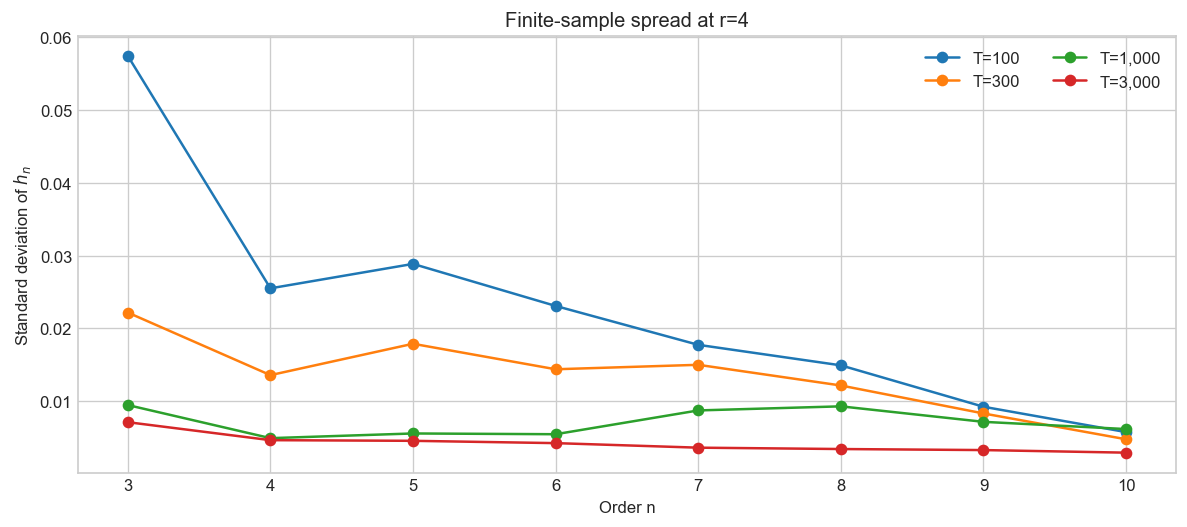

In [19]:
fig, ax = plt.subplots()
for length, group in finite_summary_df.groupby("T"):
    ax.plot(group["n"], group["std_h"], marker="o", label=f"T={length:,}")
ax.set(
    xlabel="Order n",
    ylabel="Standard deviation of $h_n$",
    title="Finite-sample spread at r=4",
)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

### 8.3 Pattern-space coverage diagnostic

When $n!$ becomes comparable to or larger than $T$, the empirical distribution is undersampled. The coverage table and heat map expose this source of bias.

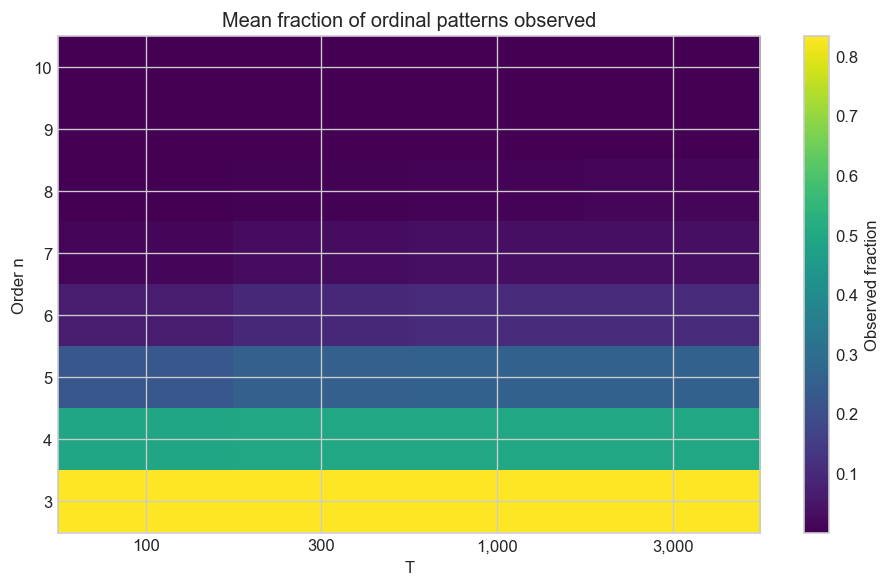

,T,n,possible_patterns,mean_observed_patterns,mean_observed_fraction
0,100,3,6,5.000000,0.833333
1,100,4,24,11.750000,0.489583
2,100,5,120,27.000000,0.225000
3,100,6,720,48.916667,0.067940
4,100,7,5040,68.333333,0.013558
5,100,8,40320,80.500000,0.001997
6,100,9,362880,86.583333,0.000239
7,100,10,3628800,88.333333,0.000024
8,300,3,6,5.000000,0.833333
9,300,4,24,12.000000,0.500000


In [20]:
coverage_table = finite_summary_df.pivot(
    index="n", columns="T", values="mean_observed_fraction"
)

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(coverage_table, aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(
    range(len(coverage_table.columns)),
    labels=[f"{value:,}" for value in coverage_table.columns],
)
ax.set_yticks(range(len(coverage_table.index)), labels=coverage_table.index)
ax.set(xlabel="T", ylabel="Order n", title="Mean fraction of ordinal patterns observed")
fig.colorbar(image, ax=ax, label="Observed fraction")
fig.tight_layout()
plt.show()

finite_summary_df[[
    "T",
    "n",
    "possible_patterns",
    "mean_observed_patterns",
    "mean_observed_fraction",
]]

### 8.4 Stability of $h_6$

The paper reports that order 6 can be estimated reasonably well from approximately 1,000 values.

In [21]:
h6_stability_df = finite_summary_df.loc[
    finite_summary_df["n"] == 6,
    ["T", "mean_h", "std_h", "mean_observed_fraction"],
].reset_index(drop=True)
h6_stability_df

,T,mean_h,std_h,mean_observed_fraction
0,100,1.069565,0.023097,0.067940
1,300,1.163345,0.014402,0.097569
2,1000,1.183787,0.005484,0.103819
3,3000,1.192591,0.004261,0.104167


## 9. Optional Experiment D: observational noise

Gaussian noise is added after generating the deterministic trajectory. The paper uses $σ=0.00025$ and $0.004$ for $h_{12}$.

In [22]:
def run_observational_noise_experiment(
    r_values,
    length,
    sigmas=(0.00025, 0.004),
    order=12,
    transient=TRANSIENT,
    random_state=RANDOM_SEED,
):
    """Compute PE after adding Gaussian observational noise."""
    rng = np.random.default_rng(random_state)
    records = []

    for r_index, r_value in enumerate(r_values):
        signal = generate_post_transient(r_value, length, transient=transient)
        for sigma in sigmas:
            noisy_signal = signal + rng.normal(0.0, sigma, signal.size)
            result = permutation_entropy(
                noisy_signal,
                order=order,
                tie_method="jitter",
                random_state=random_state + r_index,
            )
            records.append({
                "r": float(r_value),
                "sigma": sigma,
                "noise_type": "observational",
                f"h{order}": result.entropy_per_symbol,
            })

    return pd.DataFrame.from_records(records)

In [23]:
if RUN_OPTIONAL_NOISE:
    noise_r_values = np.linspace(R_MIN, R_MAX, N_R)
    observational_noise_df = run_observational_noise_experiment(
        noise_r_values, SWEEP_LENGTH
    )
else:
    observational_noise_df = pd.DataFrame()

observational_noise_df.head()

""


In [24]:
if not observational_noise_df.empty:
    fig, ax = plt.subplots()
    for sigma, group in observational_noise_df.groupby("sigma"):
        ax.plot(group["r"], group["h12"], label=f"sigma={sigma:g}")
    ax.set(xlabel="r", ylabel="$h_{12}$", title="Observational-noise experiment")
    ax.legend()
    fig.tight_layout()
    plt.show()

## 10. Optional Experiment E: dynamical noise

Gaussian noise is added inside the recurrence. The paper uses $σ=0.00025$, $0.001$, and $0.004$.

In [25]:
def run_dynamical_noise_experiment(
    r_values,
    length,
    sigmas=(0.00025, 0.001, 0.004),
    order=12,
    transient=TRANSIENT,
    random_state=RANDOM_SEED,
):
    """Compute PE for logistic maps with Gaussian dynamical noise."""
    records = []

    for r_index, r_value in enumerate(r_values):
        for sigma_index, sigma in enumerate(sigmas):
            seed = random_state + r_index * len(sigmas) + sigma_index
            signal = generate_post_transient(
                r=r_value,
                length=length,
                transient=transient,
                dynamical_noise=sigma,
                rng=seed,
            )
            result = permutation_entropy(
                signal,
                order=order,
                tie_method="jitter",
                random_state=seed,
            )
            records.append({
                "r": float(r_value),
                "sigma": sigma,
                "noise_type": "dynamical",
                f"h{order}": result.entropy_per_symbol,
            })

    return pd.DataFrame.from_records(records)

In [26]:
if RUN_OPTIONAL_NOISE:
    dynamical_noise_df = run_dynamical_noise_experiment(
        noise_r_values, SWEEP_LENGTH
    )
else:
    dynamical_noise_df = pd.DataFrame()

dynamical_noise_df.head()

""


In [27]:
if not dynamical_noise_df.empty:
    fig, ax = plt.subplots()
    for sigma, group in dynamical_noise_df.groupby("sigma"):
        ax.plot(group["r"], group["h12"], label=f"sigma={sigma:g}")
    ax.set(xlabel="r", ylabel="$h_{12}$", title="Dynamical-noise experiment")
    ax.legend()
    fig.tight_layout()
    plt.show()

## 11. Discussion diagnostics

The following summaries support the five discussion questions: periodic versus chaotic separation, agreement with Lyapunov structure, order dependence, factorial pattern growth, and improvement with increasing $T$.

In [28]:
regime_df = sweep_df.loc[np.isfinite(sweep_df["lyapunov"])].copy()
regime_df["regime"] = np.where(
    regime_df["lyapunov"] > 0.0, "chaotic", "periodic_or_stable"
)
regime_summary_df = (
    regime_df.groupby("regime", as_index=False)
    .agg(
        number_of_r=("r", "size"),
        mean_lyapunov=("lyapunov", "mean"),
        mean_h6=("h6", "mean"),
        mean_h12=("h12", "mean"),
    )
)
regime_summary_df

,regime,number_of_r,mean_lyapunov,mean_h6,mean_h12
0,chaotic,62,0.553753,0.873081,0.724265
1,periodic_or_stable,19,-0.319287,0.637783,0.582382


## 12. Optional result export

Set `SAVE_RESULTS=True` to export the parameter sweep, bifurcation data, finite-sample results, and any enabled noise results.

In [29]:
if SAVE_RESULTS:
    output_dir = PROJECT_ROOT / "paper_replications" / "outputs" / "bandt_2002"
    output_dir.mkdir(parents=True, exist_ok=True)
    sweep_df.to_csv(output_dir / "parameter_sweep.csv", index=False)
    bifurcation_df.to_csv(output_dir / "bifurcation.csv", index=False)
    finite_raw_df.to_csv(output_dir / "finite_sample_raw.csv", index=False)
    finite_summary_df.to_csv(output_dir / "finite_sample_summary.csv", index=False)
    if not observational_noise_df.empty:
        observational_noise_df.to_csv(
            output_dir / "observational_noise.csv", index=False
        )
    if not dynamical_noise_df.empty:
        dynamical_noise_df.to_csv(
            output_dir / "dynamical_noise.csv", index=False
        )

## 13. Interpretation checklist

A successful reproduction should show:

1. Low PE in stable periodic regions and higher PE in chaotic regions.
2. Periodic windows aligned across the Lyapunov, $h_6$, and $h_{12}$ profiles.
3. Similar global structure for $h_6$ and $h_{12}$.
4. Decreasing ordinal-pattern coverage and finite-sample bias as $n!$ approaches or exceeds $T$.
5. Relative stabilization of $h_6$ around $T$ approximately $10^3$.

Reduced-mode results validate the pipeline only. Scientific comparison with the paper should use `PAPER_SCALE=True` and report the reproduction choices explicitly.